# Compute the potential energy of a uniform sphere

In this notebook we show how to use the `PotentialEnergy` class to compute the potential energy of a sphere with uniform density initialized on a Voronoi mesh, and compare it to the analytical prediction

In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

pa.settings.strict_units = False

from paicos.util import get_index_of_radial_range as RadialRange

threadsperblock = 64

In [2]:
# A snapshot object
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
radius = 1e3*snap.length

widths = np.ones(3)*2*radius.value

Gauss = snap.uq('G')
arepo_length = snap.length
density_unit = snap['0_Density'].uq
L_box = (arepo_length*(widths[0]))

We set up a sphere with density equal to 1 inside R and 0 elsewhere

In [3]:
idx_sphere = RadialRange(snap["0_Coordinates"],
                       center, 0*radius, radius)
volumes = snap['0_Volume']
snap['0_Masses'][idx_sphere] = volumes[idx_sphere]*density_unit
snap['0_Masses'][~idx_sphere] = 0

In [4]:
smoothing_length = np.cbrt((snap["0_Volume"]) / (4.0 * np.pi / 3.0)).to('arepo_length')


The `PotentialEnergy` class divides the domain in a uniform Cartesian grid (same as for the `SmoothingFilter` class) and computes the potential energy approximating long-range interactions as point particles at the Cartesian cells, while short-range interactions are computed directly

In [5]:

pe = tc.PotentialEnergy(snap, center, widths, pos=snap['0_Coordinates'],
                        mass=snap['0_Masses'], smoothing_length=smoothing_length, npix=32,
                       threadsperblock=threadsperblock)

Mass enclosed in the sphere (theory)

In [6]:
(4./3.)*np.pi*radius**3*density_unit

<PaicosQuantity 4.1887902e+09 arepo_length3 arepo_density / small_h>

Mass enclosed in the sphere (voronoi grid)

In [7]:
Mtot = np.sum(snap['0_Masses'])
print(Mtot)

4229359864.9839416 arepo_mass / small_h


Number of particles inside the sphere:

In [8]:
np.sum(pe.index)

np.int64(12515)

The opening angle (in degrees) below which the gravitational interaction is computed directly can be given as argument when the function `compute_potential` is called:

In [9]:
pe.compute_potential(angle=15)

<PaicosQuantity -717935.56690373 m3 arepo_mass2 / (arepo_length kg small_a small_h s2)>

In [10]:
# angles = np.array([40, 25, 15, 10, 5, 2, 0])
angles = np.array([40, 25, 15, 10])

num_cells_away = 0.5*np.sqrt(3)/np.tan(0.5*angles*np.pi/180)

In [11]:
num_cells_away

array([2.37938524, 3.90638815, 6.57811602, 9.89871566])

We benchmark the execution time and the accuracy of this method by varying the opening angle

In [12]:
U_bench = []
runtime_bench = [] # in s
for angle in angles:
    U_tmp = []
    result = %timeit -n1 -r5 -o U_tmp.append(pe.compute_potential(angle=angle).to_physical.to('erg'))
    U_bench.append(U_tmp[0])
    runtime_bench.append(result.average)

674 ms ± 5.14 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
685 ms ± 4.95 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
735 ms ± 6.15 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
821 ms ± 1.53 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


We compare our method to a direct $O(N^2)$ computation:

In [13]:
from numba import njit, prange
import cupy as cp
from numba import cuda
import math


@cuda.jit()
def cuda_potential(masses, pos, hsml, potential):

    Np =  masses.shape[0]
    i = cuda.grid(1)

    if (i < Np):
        for j in range(Np):
            h = max(hsml[i], hsml[j])
            m1m2 = masses[i]*masses[j]
            if (i==j):
                potential[i] -= m1m2*(14./5.)/h
            else:
                r = math.sqrt((pos[i][0] - pos[j][0])**2 +
                             (pos[i][1] - pos[j][1])**2 +
                             (pos[i][2] - pos[j][2])**2)
                potential_tmp = m1m2/r
                
                # if (r <= h):
                #     potential_tmp *= (0.5*r/h)*(3-(r/h)**2)
                u = r/h
                if (u < 0.5):
                    potential_tmp *= (14./5.)*u - (16./3.)*u**3 + (48./5.)*u**5 - (32./5.)*u**6
                elif (u >= 0.5 and u < 1):
                    potential_tmp *= 16.*u**4 - (48./5.)*u**5 + (32./15.)*u**6
                
                potential[i] -= potential_tmp
                


def direct_calculation_cuda(snap, positions, masses, smoothing_length):
    # snap_select = snap.select(index, parttype=0)

    Np = masses.shape[0]

    if isinstance(smoothing_length.value, np.ndarray):
        assert smoothing_length.shape == masses.shape
    else:
        smoothing_length = np.ones(Np) * smoothing_length

    mass = cp.array(masses.value)
    pos = cp.array(positions.value)
    hsml = cp.array(smoothing_length.value)
    potential = cp.zeros_like(mass)

    threadsperblock = 256
    blocks_1d = (Np + (threadsperblock - 1)) // threadsperblock
    

    cuda_potential[blocks_1d, threadsperblock](mass, pos, hsml, potential)

    potential = cp.asnumpy(cp.sum(potential))
    
    G = pa.astropy.constants.G
    potential = 0.5 * G * potential * snap.mass**2 / snap.length
    return potential
    

In [14]:
U_direct = []
# runtime_direct = [] # in s
result = %timeit -n1 -r5 -o U_direct.append(direct_calculation_cuda(snap, snap['0_Coordinates'][pe.index], snap['0_Masses'][pe.index], smoothing_length[pe.index]))

U_direct = U_direct[0].to_physical.to('erg')
runtime_direct = result.average

/home/lorenzolmp/miniconda3/envs/turbocluster/lib/python3.14/site-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


111 ms ± 49.5 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [15]:
U_direct

<PaicosQuantity -1.36896196e+74 erg>

In [16]:
U_bench[-1]

<PaicosQuantity -1.36758603e+74 erg>

In [17]:
G = pa.astropy.constants.G
# https://en.wikipedia.org/wiki/Gravitational_binding_energy
U_theory = -(3./5.)*G*Mtot**2/radius
U_theory = U_theory.to_physical.to('erg')

In [18]:
U_theory

<PaicosQuantity -1.36418591e+74 erg>

In [19]:
relative_err = np.array([np.abs((U_bench[i]-U_direct)/U_direct).value for i in range(len(U_bench))])

We plot the accuracy and the execution times of the different methods in the following plot:

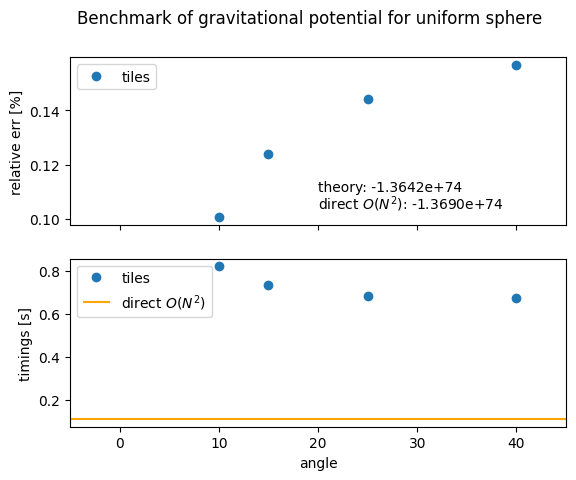

In [20]:


fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(angles, relative_err*100, ls='', marker='o', label='tiles')
ax[1].plot(angles, runtime_bench, ls='', marker='o', label='tiles')
ax[1].hlines(runtime_direct, xmin=-5, xmax=45, color='orange', ls='-', label=r'direct $O(N^2)$')

ax[0].text(0.5, 0.10, rf'direct $O(N^2)$: {U_direct.value:.4e}', transform=ax[0].transAxes)
ax[0].text(0.5, 0.20, f'theory: {U_theory.value:.4e}', transform=ax[0].transAxes)

ax[0].set_xlim(xmin=-5, xmax=45)

ax[1].set_xlabel('angle')
ax[0].set_ylabel('relative err [%]')
ax[1].set_ylabel('timings [s]')
ax[0].legend()
ax[1].legend()

fig.suptitle('Benchmark of gravitational potential for uniform sphere')

plt.show()